In [ ]:
from google.colab import files
uploaded = files.upload()  # Choose rice_disease_dataset_t1.zip

Saving rice_disease_dataset_t1.zip to rice_disease_dataset_t1.zip


In [ ]:
import zipfile

with zipfile.ZipFile('rice_disease_dataset_t1.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
train_path = '/content/rice_disease_dataset_t1/train'
test_path = '/content/rice_disease_dataset_t1/test'

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 32

train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 89 images belonging to 3 classes.
Found 30 images belonging to 3 classes.


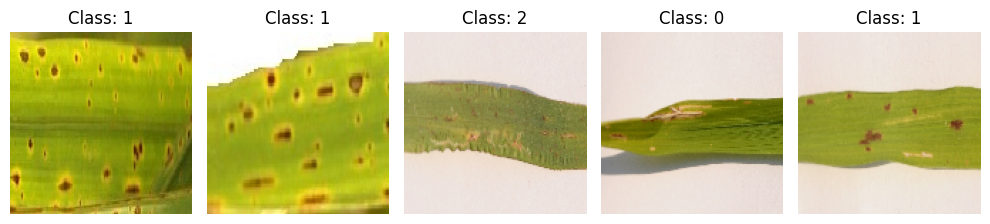

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_data)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])
    plt.title(f"Class: {np.argmax(labels[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,051 (14.14 MB)

 Trainable params: 3,706,051 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.1810 - loss: 3.0710 - val_accuracy: 0.3333 - val_loss: 1.7571
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3075 - loss: 1.6403 - val_accuracy: 0.3333 - val_loss: 1.1328
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3366 - loss: 1.1276 - val_accuracy: 0.2667 - val_loss: 1.1058
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6405 - loss: 1.0599 - val_accuracy: 0.4667 - val_loss: 1.1043
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4422 - loss: 1.0344 - val_accuracy: 0.3667 - val_loss: 1.1480
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4372 - loss: 1.0001 - val_accuracy: 0.4333 - val_loss: 1.1161
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5543 - loss: 0.8992 - val_accuracy: 0.4333 - val_loss: 1.2056
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6569 - loss: 0.8409 - val_accuracy: 0.3000 - val_loss: 1.1497
Epoch 9/10
3/3 ━

Possible overfitting

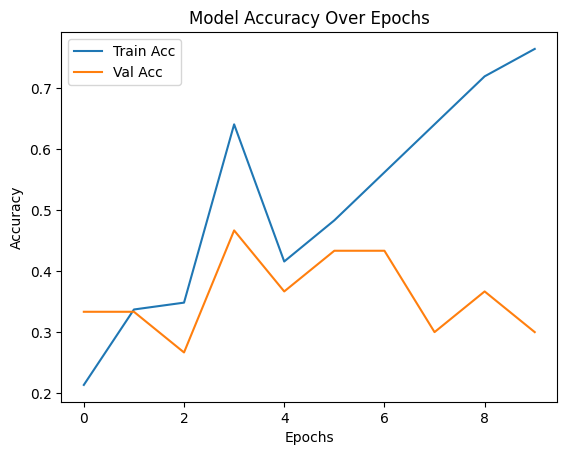

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy Over Epochs')
plt.show()

Retrying

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
Confusion Matrix:
[[7 0 3]
 [4 1 5]
 [2 7 1]]
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.54      0.70      0.61        10
           brown_spot       0.12      0.10      0.11        10
            leaf_smut       0.11      0.10      0.11        10

             accuracy                           0.30        30
            macro avg       0.26      0.30      0.28        30
         weighted avg       0.26      0.30      0.28        30



Retrying with with early stop

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True
)

Early stop

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8116 - loss: 0.6404 - val_accuracy: 0.2667 - val_loss: 1.3296
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7637 - loss: 0.6353 - val_accuracy: 0.3333 - val_loss: 1.3521
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8460 - loss: 0.4977 - val_accuracy: 0.3667 - val_loss: 1.3684
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8319 - loss: 0.4544 - val_accuracy: 0.4333 - val_loss: 1.4301


In [ ]:
best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"Best Epoch: {best_epoch}")

Best Epoch: 1


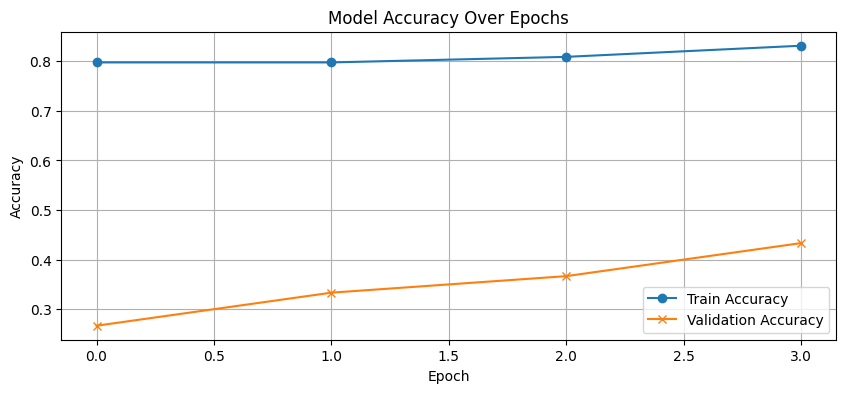

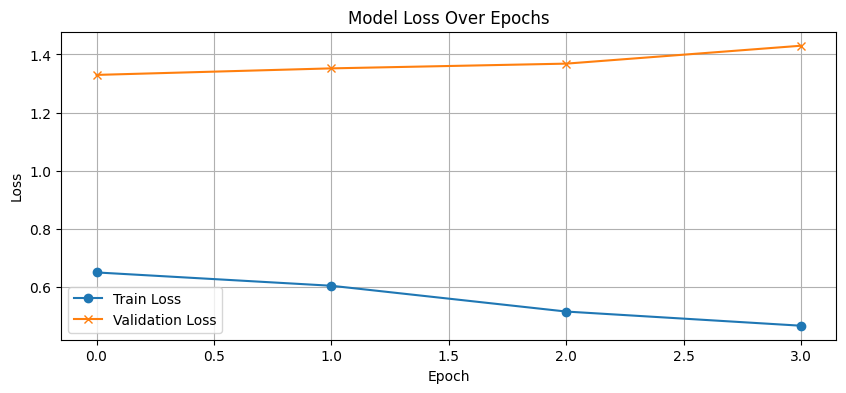

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Redoing the training with different metrics to try and improve accuracy of validation data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 89 images belonging to 3 classes.
Found 30 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3656 - loss: 2.9016 - val_accuracy: 0.3333 - val_loss: 1.1070
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4881 - loss: 1.9755 - val_accuracy: 0.3000 - val_loss: 1.1090
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4738 - loss: 1.8589 - val_accuracy: 0.2333 - val_loss: 1.1132
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5106 - loss: 1.6455 - val_accuracy: 0.2333 - val_loss: 1.1205


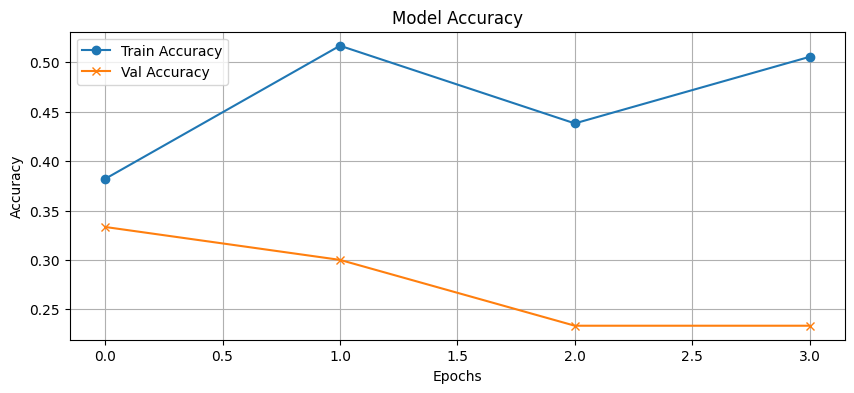

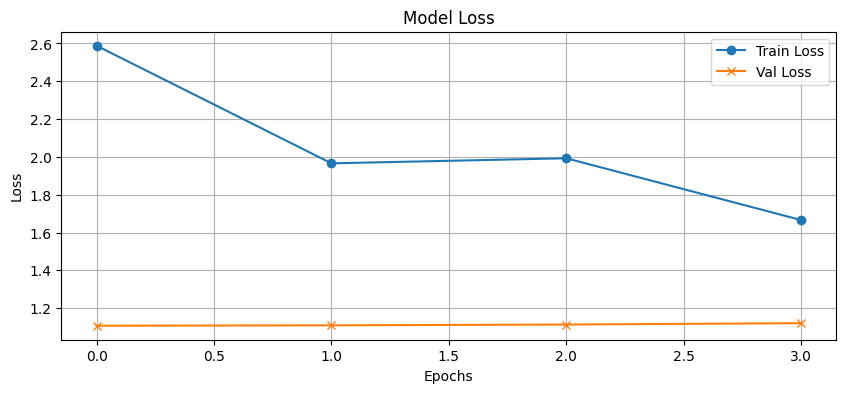

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='x')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Going back to previous specifics and retraining

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(train_data.num_classes, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2856 - loss: 1.4059 - val_accuracy: 0.3333 - val_loss: 1.1897
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.3378 - loss: 1.1896 - val_accuracy: 0.2667 - val_loss: 1.1474
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3987 - loss: 1.0675 - val_accuracy: 0.2000 - val_loss: 1.1527
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3832 - loss: 1.0616 - val_accuracy: 0.3333 - val_loss: 1.1937
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.3887 - loss: 1.0529 - val_accuracy: 0.1667 - val_loss: 1.1666
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5488 - loss: 1.0137 - val_accuracy: 0.3333 - val_loss: 1.1955
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5156 - loss: 0.9945 - val_accuracy: 0.4000 - val_loss: 1.2234
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5197 - loss: 0.9517 - val_accuracy: 0.1667 - val_loss: 1.2935
Epoch 9/15
3/3 ━

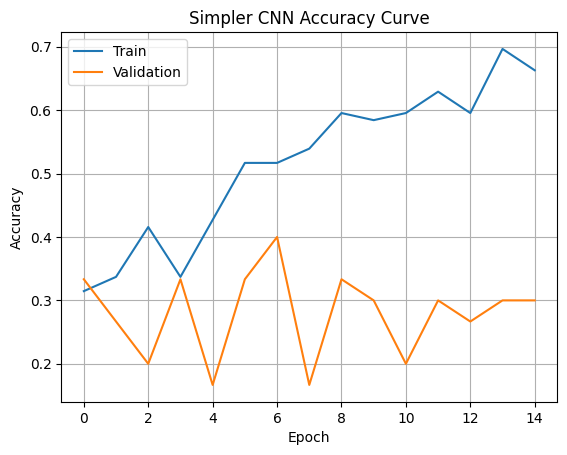

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Simpler CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

Trying the model on an sample image with confirmed blight disease

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving drice1.jpg to drice1 (1).jpg


In [ ]:
# Preprocess the uploaded image
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

# Loading image and preprocess
img = image.load_img(img_path, target_size=(128, 128))  # Match CNN input
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Normalize like training data
img_array = np.expand_dims(img_array, axis=0)  # Reshape to (1, 128, 128, 3)

In [ ]:
# Predicting with sample image
pred = model.predict(img_array)
class_idx = np.argmax(pred, axis=1)[0]
class_labels = list(train_data.class_indices.keys())
confidence = round(np.max(pred), 3) * 100

print(f"Predicted Class: {class_labels[class_idx]} ({confidence:.2f}% confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Predicted Class: brown_spot (80.80% confidence)


Prediction with image

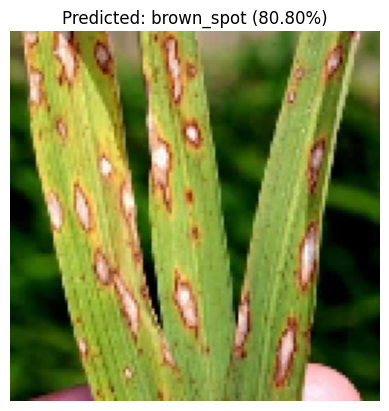

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Predicted: {class_labels[class_idx]} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

80% accuracy prediction

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Confusion Matrix:
[[8 1 1]
 [5 0 5]
 [5 4 1]]
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.44      0.80      0.57        10
           brown_spot       0.00      0.00      0.00        10
            leaf_smut       0.14      0.10      0.12        10

             accuracy                           0.30        30
            macro avg       0.20      0.30      0.23        30
         weighted avg       0.20      0.30      0.23        30



Retrying with standard models : VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze base layers to keep pretrained features
for layer in base_model.layers:
    layer.trainable = False

Adding custom classifier

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

Compiling and training

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_vgg = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 12s/step - accuracy: 0.3475 - loss: 1.1553 - val_accuracy: 0.3333 - val_loss: 1.1135
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 10s/step - accuracy: 0.3127 - loss: 1.1803 - val_accuracy: 0.3333 - val_loss: 1.0869
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 10s/step - accuracy: 0.4069 - loss: 1.1075 - val_accuracy: 0.4000 - val_loss: 1.0835
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 10s/step - accuracy: 0.3993 - loss: 1.1045 - val_accuracy: 0.3333 - val_loss: 1.0785
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 11s/step - accuracy: 0.4425 - loss: 1.0476 - val_accuracy: 0.3333 - val_loss: 1.0779
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 10s/step - accuracy: 0.4981 - loss: 1.0026 - val_accuracy: 0.3667 - val_loss: 1.0884
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 12s/step - accuracy: 0.4444 - loss: 1.0099 - val_accuracy: 0.3667 - val_loss: 1.0978
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 14s/step - accuracy: 0.5993 - loss: 0.9182 - val_accuracy: 0.3000 - val_loss: 1.1043


Accuracy plot for VGG16

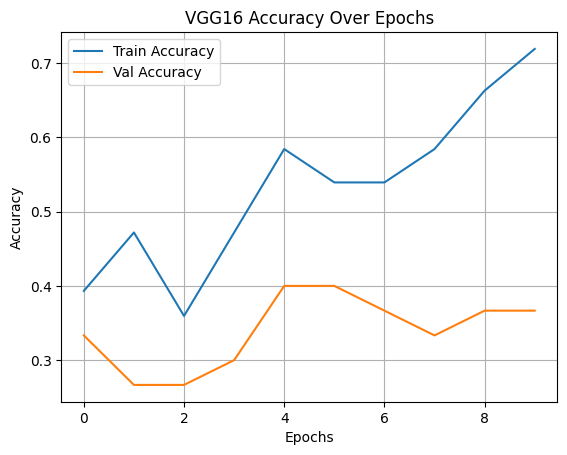

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16 Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Confusion matrix for VGG16

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

resnet_preds = model.predict(test_data)
y_pred_resnet = np.argmax(resnet_preds, axis=1)
y_true = test_data.classes

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_resnet))
print("Classification Report:\n", classification_report(y_true, y_pred_resnet, target_names=list(test_data.class_indices.keys())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Confusion Matrix:
 [[8 1 1]
 [5 0 5]
 [5 4 1]]
Classification Report:
                        precision    recall  f1-score   support

bacterial_leaf_blight       0.44      0.80      0.57        10
           brown_spot       0.00      0.00      0.00        10
            leaf_smut       0.14      0.10      0.12        10

             accuracy                           0.30        30
            macro avg       0.20      0.30      0.23        30
         weighted avg       0.20      0.30      0.23        30



Retrying with standard models : ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Adding custom classifier

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

Compile and train with 10 epochs

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.3375 - loss: 1.2643 - val_accuracy: 0.3333 - val_loss: 1.1097
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.2906 - loss: 1.2045 - val_accuracy: 0.3333 - val_loss: 1.1518
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.3615 - loss: 1.2219 - val_accuracy: 0.4000 - val_loss: 1.1225
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.3478 - loss: 1.2338 - val_accuracy: 0.3333 - val_loss: 1.1064
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.2984 - loss: 1.1594 - val_accuracy: 0.3333 - val_loss: 1.1091
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.2875 - loss: 1.2017 - val_accuracy: 0.3333 - val_loss: 1.1176
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.3248 - loss: 1.2259 - val_accuracy: 0.3333 - val_loss: 1.1107
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.4394 - loss: 1.0772 - val_accuracy: 0.3000 - val_loss: 1.1003
Epoch 9/10
3/

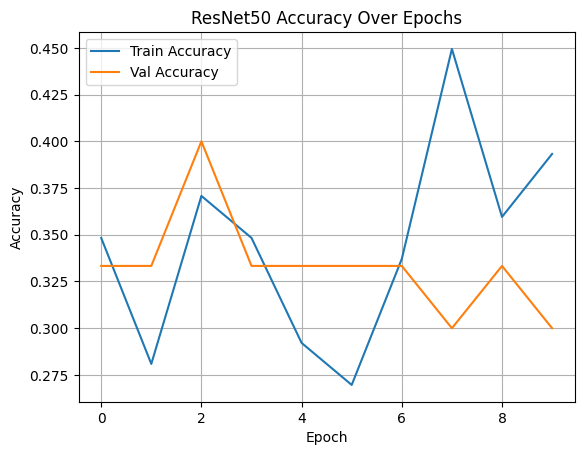

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50 Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Unfreeze the last few layers
for layer in base_model.layers[-10:]:
    layer.trainable = True

In [ ]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

Confusion matrix : ResNet50

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

resnet_preds = model.predict(test_data)
y_pred_resnet = np.argmax(resnet_preds, axis=1)
y_true = test_data.classes

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_resnet))
print("Classification Report:\n", classification_report(y_true, y_pred_resnet, target_names=list(test_data.class_indices.keys())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Confusion Matrix:
 [[ 0  0 10]
 [ 0  0 10]
 [ 0  1  9]]
Classification Report:
                        precision    recall  f1-score   support

bacterial_leaf_blight       0.00      0.00      0.00        10
           brown_spot       0.00      0.00      0.00        10
            leaf_smut       0.31      0.90      0.46        10

             accuracy                           0.30        30
            macro avg       0.10      0.30      0.15        30
         weighted avg       0.10      0.30      0.15        30



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Compariosion of all three models : confusion matrix for Custom CNN vs VGG16 vs ResNet50

> Add blockquote



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

resnet_preds = model.predict(test_data)
y_pred_resnet = np.argmax(resnet_preds, axis=1)
y_true = test_data.classes

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_resnet))
print("Classification Report:\n", classification_report(y_true, y_pred_resnet, target_names=list(test_data.class_indices.keys())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Confusion Matrix:
 [[ 0  0 10]
 [ 0  0 10]
 [ 0  1  9]]
Classification Report:
                        precision    recall  f1-score   support

bacterial_leaf_blight       0.00      0.00      0.00        10
           brown_spot       0.00      0.00      0.00        10
            leaf_smut       0.31      0.90      0.46        10

             accuracy                           0.30        30
            macro avg       0.10      0.30      0.15        30
         weighted avg       0.10      0.30      0.15        30



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Graphical visualization of the Comparision between 3 models

In [ ]:
vgg_preds = model.predict(test_data)
y_pred_vgg = np.argmax(vgg_preds, axis=1)
y_true = test_data.classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


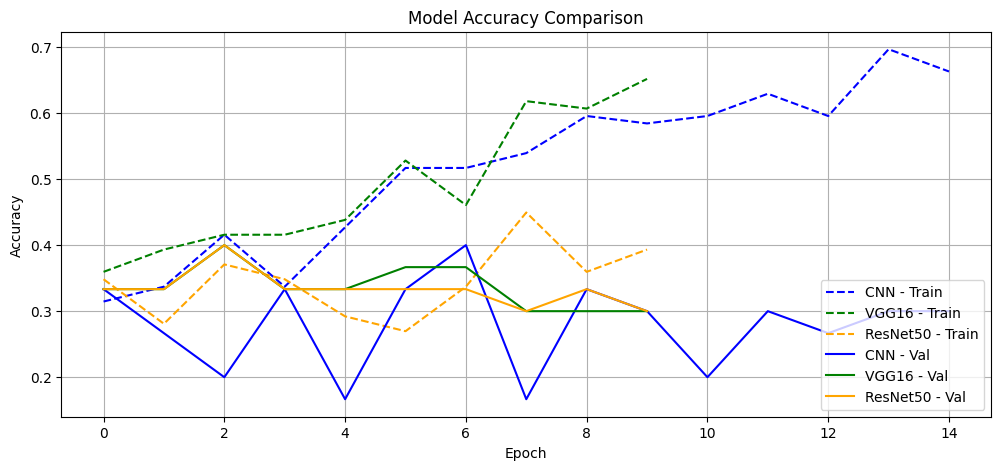

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Training accuracy
plt.plot(history.history['accuracy'], label='CNN - Train', linestyle='--', color='blue')
plt.plot(history_vgg.history['accuracy'], label='VGG16 - Train', linestyle='--', color='green')
plt.plot(history_resnet.history['accuracy'], label='ResNet50 - Train', linestyle='--', color='orange')

# Validation accuracy
plt.plot(history.history['val_accuracy'], label='CNN - Val', color='blue')
plt.plot(history_vgg.history['val_accuracy'], label='VGG16 - Val', color='green')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50 - Val', color='orange')

plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()